In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm
import colorcet as ccm
import gsw

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41240 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41240/status,
Dashboard: http://127.0.0.1:41240/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41647,Workers: 0
Dashboard: http://127.0.0.1:41240/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42930,Total threads: 6
Dashboard: http://127.0.0.1:42155/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:34834,


In [4]:
from xmitgcm import open_mdsdataset

In [5]:
from utils import *

In [6]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [7]:
data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

ISOBLJ = ISOBLJ_Struct(input_data,data=data)

In [8]:
# ISOBLJ.data
ISOBLJ.open_datasets(prefix=['state2D','scalars'],endian=">")

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
ISOBLJ.data['dz8']['expt'].pop("c80m_Td2_vshift8_ryan_dz8")
ISOBLJ.data['dz4']['expt'].pop("c80m_Td2_vshift16_ryan_dz4")

{'exec': True,
 'dims': {'nx': np.float64(60.0),
  'ny': np.float64(160.0),
  'nz': np.float64(128.0),
  'dx': np.float64(60.0),
  'dy': np.float64(60.0),
  'dz': np.float64(4.0)},
 'timestep': array(4.),
 'data': <xarray.Dataset> Size: 3GB
 Dimensions:   (XC: 60, YC: 160, XG: 60, YG: 160, Z: 128, Zp1: 129, Zu: 128,
                Zl: 128, time: 180)
 Coordinates: (12/34)
   * XC        (XC) float32 240B 0.03 0.09 0.15 0.21 0.27 ... 3.39 3.45 3.51 3.57
   * YC        (YC) float32 640B 0.03 0.09 0.15 0.21 0.27 ... 9.39 9.45 9.51 9.57
   * XG        (XG) float32 240B 0.0 0.06 0.12 0.18 0.24 ... 3.36 3.42 3.48 3.54
   * YG        (YG) float32 640B 0.0 0.06 0.12 0.18 0.24 ... 9.36 9.42 9.48 9.54
   * Z         (Z) >f4 512B -2.0 -6.0 -10.0 -14.0 ... -498.0 -502.0 -506.0 -510.0
   * Zp1       (Zp1) >f4 516B 0.0 -4.0 -8.0 -12.0 ... -500.0 -504.0 -508.0 -512.0
     ...        ...
     dxF       (YC, XC) >f4 38kB dask.array<chunksize=(160, 60), meta=np.ndarray>
     rhoRef    (Z) >f4 512B dask

In [10]:
temp = ISOBLJ.get_variable("THETA")
SHIfwFlx = ISOBLJ.get_variable("SHIfwFlx")
Ustar = ISOBLJ.get_variable("SHIuStar")
SHI_TmTb = ISOBLJ.get_variable("SHI_TmTb")

In [11]:
RHOAnoma = ISOBLJ.get_variable("RHOAnoma")
RHOAnoma = RHOAnoma.where(RHOAnoma>-25)

In [12]:
# temp=temp.sel(time=slice(6,720))
# SHIfwFlx=SHIfwFlx.sel(time=slice(6,720))
# Ustar=Ustar.sel(time=slice(6,720))
# RHOAnoma=RHOAnoma.sel(time=slice(6,720))

In [13]:
# T_freezing=xr.open_dataset("freezing_temperatures.nc")
# T_freezing =T_freezing.drop_vars([coord for coord in T_freezing.coords if "hFacC" in coord])

# T_ref = gsw.CT_freezing(34.5,300,0)
# T_ref

In [14]:
# np.sort(Uvel.data_vars)
import re

def tryint(s):
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """ Turn a string into a list of string and number chunks.
        "z23a" -> ["z", 23, "a"]
    """
    return [ tryint(c) for c in re.split('([0-9]+)', s) ]

def sort_nicely(l):
    """ Sort the given list in the way that humans expect.
    """
    l.sort(key=alphanum_key)

var_names = list(SHIfwFlx.data_vars)
sort_nicely(var_names)

In [15]:
SHIfwFlx

<xarray.Dataset> Size: 726MB
Dimensions:                              (XC: 60, YC: 160, time: 180)
Coordinates:
  * XC                                   (XC) float32 240B 0.03 0.09 ... 3.57
  * YC                                   (YC) float32 640B 0.03 0.09 ... 9.57
  * time                                 (time) float64 1kB 6.0 ... 1.08e+03
    rA                                   (YC, XC) >f4 38kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    Depth                                (YC, XC) >f4 38kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    dxF                                  (YC, XC) >f4 38kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    dyF                                  (YC, XC) >f4 38kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    iter                                 (time) int64 1kB dask.array<chunksize=(1,), meta=np.ndarray>
Data variables: (12/105)
    SHIfwFlx_c0m_Td1_vshift12_dz8        (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c20m_Td05_vshift12_dz8      (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c160m_Td01_vshift12_dz8     (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c80m_Td2_vshift12_dz8       (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c40m_Td1_vshift12_dz8       (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c120m_Td1_vshift12_dz8      (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    ...                                   ...
    SHIfwFlx_c80m_Td1_vshift32_dz2       (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c80m_Td01_vshift16_dz2      (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c80m_Td05_vshift64_dz2      (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c80m_Td05_vshift48_dz2      (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c80m_Td2_vshift16_dz2       (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
    SHIfwFlx_c80m_Td01_vshift64_dz2      (time, YC, XC) float32 7MB dask.array<chunksize=(1, 160, 60), meta=np.ndarray>
Attributes:
    standard_name:  SHIfwFlx
    long_name:      Ice shelf fresh water flux (positive upward)
    units:          kg/m^2/s

In [16]:
seconds_per_year = 365*24*3600

M = -((SHIfwFlx* seconds_per_year)/1030 )
M_mean = M.mean(("YC","XC")).compute()

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 44.21 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [17]:
M_std = M.std(("YC","XC")).compute()

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 44.24 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.div

In [18]:
from matplotlib.gridspec import GridSpec

In [19]:
def coord_dtype(ds):
    for coord in ds.coords:
        ds[coord]= ds[coord].astype(np.float64)
    return ds

In [20]:
temp_shift = coord_dtype(shifted_dataset(temp,method = "ud").astype(float))

In [21]:
for var in temp_shift.data_vars:
    hfacc_var = var.replace("THETA","hFacC")
    
    hfacc_shifted = shifted_computations(temp_shift[hfacc_var], method="ud",dims=["Z_dz{0}".format(var.split("dz")[-1])] )
    temp_shift[hfacc_var] = hfacc_shifted
    # temp_shift[var] = temp_shift[var]

In [22]:
def select_top_cells(ds,n=2):
    new_dataset=[]
    for var in ds.data_vars:
        z = "Z_dz{0}".format(var.split("dz")[-1])
        new_dataset.append(ds[var].isel({z:slice(0,n)}))
        # hfacc_shifted = shifted_computations(temp_shift[hfacc_var], method="ud",dims=[)
    top_cells = xr.merge(new_dataset)
    return top_cells

In [23]:
top_temp = select_top_cells(temp_shift,n=2)
top_temp

<xarray.Dataset> Size: 3GB
Dimensions:                           (XC: 60, YC: 160, Z_dz8: 2, time: 180,
                                       Z_dz4: 2, Z_dz2: 2)
Coordinates: (12/230)
  * XC                                (XC) float64 480B 0.03 0.09 ... 3.51 3.57
  * YC                                (YC) float64 1kB 0.03 0.09 ... 9.51 9.57
  * Z_dz8                             (Z_dz8) float64 16B -4.0 -12.0
  * time                              (time) float64 1kB 6.0 12.0 ... 1.08e+03
    rA                                (YC, XC) float64 77kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    Depth                             (YC, XC) float64 77kB dask.array<chunksize=(160, 60), meta=np.ndarray>
    ...                                ...
    hFacC_c80m_Td05_vshift48_dz2      (YC, XC, Z_dz2) float64 154kB dask.array<chunksize=(160, 60, 2), meta=np.ndarray>
    maskC_c80m_Td05_vshift48_dz2      (Z_dz2, YC, XC) float64 154kB dask.array<chunksize=(2, 160, 60), meta=np.ndarray>
    hFacC_c80m_Td2_vshift16_dz2       (YC, XC, Z_dz2) float64 154kB dask.array<chunksize=(160, 60, 2), meta=np.ndarray>
    maskC_c80m_Td2_vshift16_dz2       (Z_dz2, YC, XC) float64 154kB dask.array<chunksize=(2, 160, 60), meta=np.ndarray>
    hFacC_c80m_Td01_vshift64_dz2      (YC, XC, Z_dz2) float64 154kB dask.array<chunksize=(160, 60, 2), meta=np.ndarray>
    maskC_c80m_Td01_vshift64_dz2      (Z_dz2, YC, XC) float64 154kB dask.array<chunksize=(2, 160, 60), meta=np.ndarray>
Data variables: (12/105)
    THETA_c0m_Td1_vshift12_dz8        (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c20m_Td05_vshift12_dz8      (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c160m_Td01_vshift12_dz8     (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td2_vshift12_dz8       (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c40m_Td1_vshift12_dz8       (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c120m_Td1_vshift12_dz8      (time, YC, XC, Z_dz8) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    ...                                ...
    THETA_c80m_Td1_vshift32_dz2       (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td01_vshift16_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td05_vshift64_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td05_vshift48_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td2_vshift16_dz2       (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>
    THETA_c80m_Td01_vshift64_dz2      (time, YC, XC, Z_dz2) float64 28MB dask.array<chunksize=(1, 160, 60, 2), meta=np.ndarray>

In [24]:
temp_shift_slice = temp_shift.sel(time=slice(6,720))

In [25]:
def VAR_withBL_TopZ(ds,var='THETA'):
    ds_return=[]
    for dvar in ds.data_vars:
        # print(dvar)
        data = ds.reset_coords(drop=True)[dvar]
        dz = int(dvar.split("dz")[-1])
        z_coord = "Z_dz{0}".format(dz)
        hfacc_var = dvar.replace(var,"hFacC")
        #This only works for a constant dz
        drK0 = ds[hfacc_var].isel({z_coord:0}) * dz
        drK1 = (1 - ds[hfacc_var].isel({z_coord:0})) * dz
        
        recip_drLoc = 1/ ( drK0 + drK1 )

        tvar = (data.isel({z_coord:0}) * drK0 + data.isel({z_coord:1}) * drK1)#.compute()

        weighted_var = tvar*recip_drLoc
        ds_return.append(weighted_var.rename(dvar.replace(var,'Tf')))
        # break
        
    return xr.merge(ds_return)
    # return weighted_var

In [26]:
RdrLoc = VAR_withBL_TopZ(temp_shift_slice)
# top_temp.THETA_c80m_Td2_vshift12_dz8.isel(time=-1, Z_dz8=0).plot()

In [27]:
# RdrLoc.to_netcdf("thermal_drives.nc")
# RdrLoc = xr.open_dataset("thermal_drives.nc").isel(time=-1)
RdrLoc = SHI_TmTb

In [28]:
# RdrLoc
# # T_freezing

# def compute_freezing(T,T_b):
#     ds_return=[]
#     for dvar in T.data_vars:
#         if "ryan" in dvar:
#             continue
#         T_drive = T[dvar] - T_b[dvar.replace("Tf","T_freezing")]
#         ds_return.append(T_drive.rename(dvar.replace("Tf","Tdrive")))
#     return xr.merge(ds_return)
        
# TD = compute_freezing(RdrLoc, T_freezing)

# TD = RdrLoc- T_ref

SHIfwFlx_c80m_Td2_vshift16_dz2
SHIfwFlx_c80m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift32_dz2
SHIfwFlx_c80m_Td2_vshift64_dz2


/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


SHIfwFlx_c0m_Td2_vshift48_dz2
SHIfwFlx_c160m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift48_visc_dz2
SHIfwFlx_c80m_Td2_vshift16_dz4
SHIfwFlx_c120m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift32_dz4
SHIfwFlx_c20m_Td2_vshift24_dz4
SHIfwFlx_c160m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift8_dz4
SHIfwFlx_c60m_Td2_vshift24_dz4
SHIfwFlx_c0m_Td2_vshift24_dz4
SHIfwFlx_c40m_Td2_vshift24_dz4
SHIfwFlx_c120m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift16_dz8
SHIfwFlx_c60m_Td2_vshift12_dz8
SHIfwFlx_c160m_Td2_vshift12_dz8
SHIfwFlx_c20m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift4_dz8
SHIfwFlx_c0m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift8_dz8
SHIfwFlx_c40m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift12_dz8


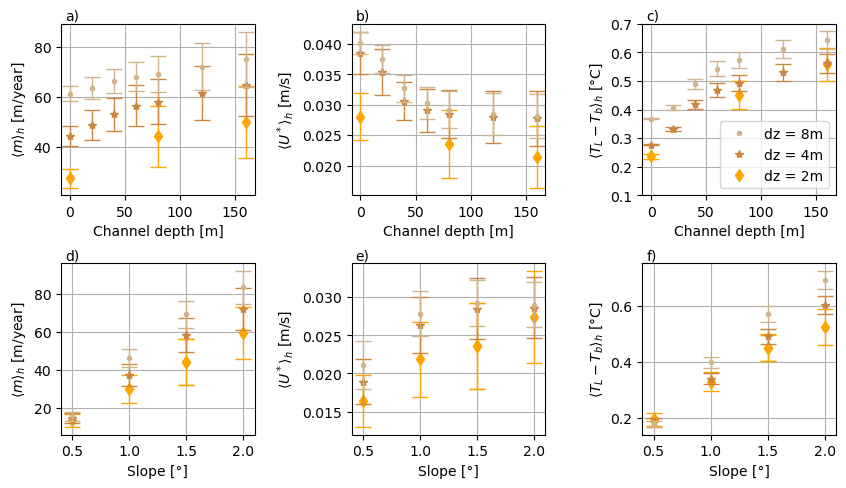

In [29]:

fig = plt.figure(figsize=(10,10))

gs = GridSpec(7, 3, figure=fig)
######## Time series ##########
ax1 = fig.add_subplot(gs[3:5,  0])
ax2 = fig.add_subplot(gs[5::, 0])
ax3 = fig.add_subplot(gs[3:5, 1])
ax4 = fig.add_subplot(gs[5::, 1])
ax5 = fig.add_subplot(gs[3:5, 2])
ax6 = fig.add_subplot(gs[5::, 2])


for var in np.flip(M_mean.data_vars):
    if "ryan" in var:
        continue
    
    if "dz8" in var:
        color="tan"
        marker="."
    elif "dz4" in var:
        color="peru"
        marker="*"
    elif "dz2" in var:
        color="orange"
        marker="d"
        
    if "c80m" in var:
        linestyle="-"
    elif "c160m" in var:
        linestyle="--"
    elif "c0m" in var:
        linestyle="-."
    
##### Melt rate vs Channel #####

    cond = ("vshift12_dz8" in var or "vshift24_dz4" in var or "vshift48_dz2" in var)
    
    if "Td2" in var and cond:
        print(var)
        channel = int(var.split("_c")[1].split("m_")[0]) 
        Melt = M[var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Melt_std = M[var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax1.plot(channel, Melt, marker=marker, color=color)
        ax1.errorbar(channel , Melt,  Melt_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)

##### U star vs Channel #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        channel = int(var.split("_c")[1].split("m_")[0]) 
        Ustar_plot = Ustar[ustar_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Ustar_std = Ustar[ustar_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax3.plot(channel, Ustar_plot, marker=marker, color=color)
        ax3.errorbar(channel , Ustar_plot,  Ustar_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
        
##### TD vs Channel #####
        channel = int(var.split("_c")[1].split("m_")[0]) 
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Tf_std = RdrLoc[tf_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax5.plot(channel, Tf, marker=marker, color=color)
        ax5.errorbar(channel , Tf,  Tf_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)

    cond=True
    
    if "Td2" in var and "c80m" in var and cond:
        print(var)
        dz_exp = int(var.split("dz")[1])
        # slope =  0.89/4 * float(var.split("_vshift")[1].split("_")[0])/(8/dz_exp)
        slope =  0.5/4 * float(var.split("_vshift")[1].split("_")[0])/(8/dz_exp)
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        Melt = M[var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Melt_std = M[var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax2.plot(slope, Melt, marker=marker, color=color)
        ax2.errorbar(slope , Melt,  Melt_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)

        ##### U star vs Channel #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        Ustar_plot = Ustar[ustar_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Ustar_std = Ustar[ustar_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax4.plot(slope, Ustar_plot, marker=marker, color=color)
        ax4.errorbar(slope , Ustar_plot,  Ustar_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)

        ##### TD vs Channel #####
    
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Tf_std = RdrLoc[tf_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax6.plot(slope, Tf, marker=marker, color=color)
        ax6.errorbar(slope , Tf,  Tf_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)


ax1.set_ylabel(r"$\left<m\right>_h$ [m/year]")
ax2.set_ylabel(r"$\left<m\right>_h$ [m/year]")
ax3.set_ylabel(r"$\left<U^*\right>_h$"+" [m/s]")
ax4.set_ylabel(r"$\left<U^*\right>_h$"+" [m/s]")
ax5.set_ylabel(r"$\left<T_L-T_b\right>_h$"+" [°C]")
ax6.set_ylabel(r"$\left<T_L-T_b\right>_h$"+" [°C]")

ax5.plot(0,0,color="tan",marker=".",label="dz = 8m",linestyle='')
ax5.plot(0,0,color="peru",marker="*",label="dz = 4m",linestyle='')
ax5.plot(0,0,color="orange",marker="d",label="dz = 2m",linestyle='')
ax5.set_ylim((0.1,0.7))

ax5.legend()

[a.grid() for a in [ax1,ax2,ax3,ax4,ax5,ax6]]
[a.set_xlabel("Channel depth [m]") for a in [ax1,ax3,ax5]]

[a.set_xlabel("Slope [°]") for a in [ax2,ax4,ax6]]
[a.set_xlim(0.4,2.1) for a in [ax2,ax4,ax6]]

plt.subplots_adjust(wspace=0.5, hspace=1.3)

ax1.text(0.02, 1.02, "a)", fontsize=10, transform=ax1.transAxes)
ax3.text(0.02, 1.02, "b)", fontsize=10, transform=ax3.transAxes)
ax5.text(0.02, 1.02, "c)", fontsize=10, transform=ax5.transAxes)
ax2.text(0.02, 1.02, "d)", fontsize=10, transform=ax2.transAxes)
ax4.text(0.02, 1.02, "e)", fontsize=10, transform=ax4.transAxes)
ax6.text(0.02, 1.02, "f)", fontsize=10, transform=ax6.transAxes)

plt.savefig('./figures/Fig_11_channel_slope.pdf', dpi=300, bbox_inches='tight')

SHIfwFlx_c80m_Td2_vshift16_dz2
SHIfwFlx_c80m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift32_dz2
SHIfwFlx_c80m_Td2_vshift64_dz2
SHIfwFlx_c0m_Td2_vshift48_dz2
SHIfwFlx_c160m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift48_visc_dz2
SHIfwFlx_c80m_Td2_vshift16_dz4
SHIfwFlx_c120m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift32_dz4
SHIfwFlx_c20m_Td2_vshift24_dz4
SHIfwFlx_c160m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift8_dz4
SHIfwFlx_c60m_Td2_vshift24_dz4
SHIfwFlx_c0m_Td2_vshift24_dz4
SHIfwFlx_c40m_Td2_vshift24_dz4
SHIfwFlx_c120m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift16_dz8
SHIfwFlx_c60m_Td2_vshift12_dz8
SHIfwFlx_c160m_Td2_vshift12_dz8
SHIfwFlx_c20m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift4_dz8
SHIfwFlx_c0m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift8_dz8
SHIfwFlx_c40m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift12_dz8
SHIfwFlx_c80m_Td2_vshift12_dz8


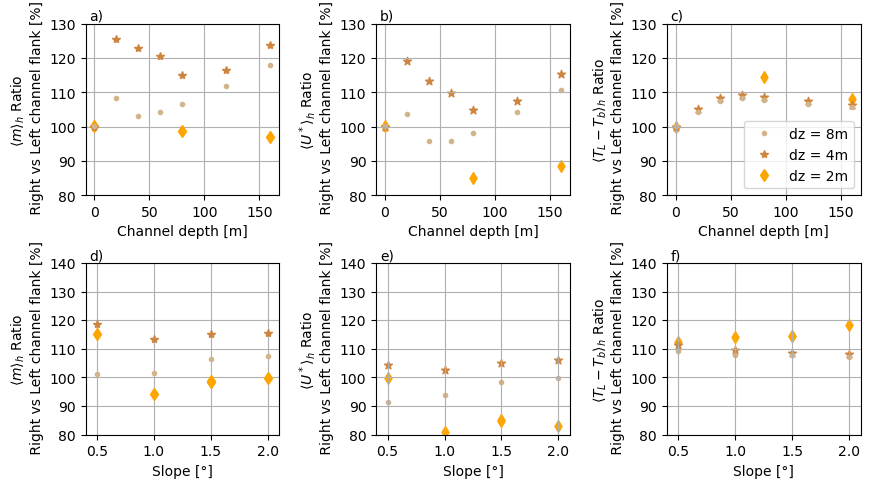

In [30]:

fig = plt.figure(figsize=(10,10))

gs = GridSpec(7, 3, figure=fig)
######## Time series ##########
ax1 = fig.add_subplot(gs[3:5,  0])
ax2 = fig.add_subplot(gs[5::, 0])
ax3 = fig.add_subplot(gs[3:5, 1])
ax4 = fig.add_subplot(gs[5::, 1])
ax5 = fig.add_subplot(gs[3:5, 2])
ax6 = fig.add_subplot(gs[5::, 2])


for var in np.flip(M_mean.data_vars):
    if "ryan" in var:
        continue
    
    if "dz8" in var:
        color="tan"
        marker="."
    elif "dz4" in var:
        color="peru"
        marker="*"
    elif "dz2" in var:
        color="orange"
        marker="d"
        
    if "c80m" in var:
        linestyle="-"
    elif "c160m" in var:
        linestyle="--"
    elif "c0m" in var:
        linestyle="-."
    
##### Melt rate vs Channel #####

    cond = ("vshift12_dz8" in var or "vshift24_dz4" in var or "vshift48_dz2" in var)
    
    if "Td2" in var and cond:
        print(var)
        channel = int(var.split("_c")[1].split("m_")[0]) 
        Melt = M[var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Melt_std = M[var].std(("XC","YC")).dropna("time").isel(time=-1)
        
##### Left vs Right Melt #####
        channel = int(var.split("_c")[1].split("m_")[0]) 
        ratio_M = ((M[var].isel(YC=slice(80,100)).mean(("XC","YC")) / M[var].isel(YC=slice(60,80)).mean(("XC","YC")))*100).dropna("time").isel(time=-1)
        ax1.plot(channel, ratio_M, marker=marker, color=color)

##### U star vs Channel #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        channel = int(var.split("_c")[1].split("m_")[0]) 
        Ustar_plot = Ustar[ustar_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Ustar_std = Ustar[ustar_var].std(("XC","YC")).dropna("time").isel(time=-1)
        
##### Left vs right U star #####
        ratio_Us = ((Ustar[ustar_var].isel(YC=slice(80,100)).mean(("XC","YC")) / Ustar[ustar_var].isel(YC=slice(60,80)).mean(("XC","YC")))*100).dropna("time").isel(time=-1)
        ax3.scatter(channel, ratio_Us, marker=marker, color=color)

##### TD vs Channel #####
        channel = int(var.split("_c")[1].split("m_")[0]) 
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Tf_std = RdrLoc[tf_var].std(("XC","YC")).dropna("time").isel(time=-1)
        
##### Left vs right TD #####
        ratio_Td = ((RdrLoc[tf_var].isel(YC=slice(80,100)).mean(("XC","YC")) / RdrLoc[tf_var].isel(YC=slice(60,80)).mean(("XC","YC")))*100).dropna("time").isel(time=-1)
        ax5.scatter(channel, ratio_Td, marker=marker, color=color)
        
    cond=True
    
    if "Td2" in var and "c80m" in var and cond:
        print(var)
        dz_exp = int(var.split("dz")[1])
        # slope =  0.89/4 * float(var.split("_vshift")[1].split("_")[0])/(8/dz_exp)
        slope =  0.5/4 * float(var.split("_vshift")[1].split("_")[0])/(8/dz_exp)
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        Melt = M[var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Melt_std = M[var].std(("XC","YC")).dropna("time").isel(time=-1)

        ##### Left vs Right Melt #####
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        ratio_M = ((M[var].isel(YC=slice(80,100)).mean(("XC","YC")) / M[var].isel(YC=slice(60,80)).mean(("XC","YC")))*100).dropna("time").isel(time=-1)
        ax2.plot(slope, ratio_M, marker=marker, color=color)

        ##### U star vs Channel #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        Ustar_plot = Ustar[ustar_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Ustar_std = Ustar[ustar_var].std(("XC","YC")).dropna("time").isel(time=-1)
        
        ##### Left vs right U star #####
        ratio_Us = ((Ustar[ustar_var].isel(YC=slice(80,100)).mean(("XC","YC")) / Ustar[ustar_var].isel(YC=slice(60,80)).mean(("XC","YC")))*100).dropna("time").isel(time=-1)
        ax4.scatter(slope, ratio_Us, marker=marker, color=color)

        ##### TD vs Channel #####
        # channel = int(var.split("_c")[1].split("m_")[0]) 
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Tf_std = RdrLoc[tf_var].std(("XC","YC")).dropna("time").isel(time=-1)

        ##### Left vs right TD #####
        ratio_Td = ((RdrLoc[tf_var].isel(YC=slice(80,100)).mean(("XC","YC")) / RdrLoc[tf_var].isel(YC=slice(60,80)).mean(("XC","YC")))*100).dropna("time").isel(time=-1)
        ax6.scatter(slope, ratio_Td, marker=marker, color=color)


ax1.set_ylabel(r"$\left<m\right>_h$" + " Ratio \n Right vs Left channel flank [%]")
ax2.set_ylabel(r"$\left<m\right>_h$" + " Ratio \n Right vs Left channel flank [%]")
ax3.set_ylabel(r"$\left<U^*\right>_h$"+ " Ratio \n Right vs Left channel flank [%]")
ax4.set_ylabel(r"$\left<U^*\right>_h$"+ " Ratio \n Right vs Left channel flank [%]")
ax5.set_ylabel(r"$\left<T_L-T_b\right>_h$"+ " Ratio \n Right vs Left channel flank [%]")
ax6.set_ylabel(r"$\left<T_L-T_b\right>_h$"+ " Ratio \n Right vs Left channel flank [%]")

ax5.plot(0,0,color="tan",marker=".",label="dz = 8m",linestyle='')
ax5.plot(0,0,color="peru",marker="*",label="dz = 4m",linestyle='')
ax5.plot(0,0,color="orange",marker="d",label="dz = 2m",linestyle='')

ax5.legend()

[a.grid() for a in [ax1,ax2,ax3,ax4,ax5,ax6]]
[a.set_xlabel("Channel depth [m]") for a in [ax1,ax3,ax5]]

[a.set_xlabel("Slope [°]") for a in [ax2,ax4,ax6]]
[a.set_xlim(0.4,2.1) for a in [ax2,ax4,ax6]]

[a.set_ylim((80,130)) for a in [ax1,ax3,ax5]]
[a.set_ylim((80,140)) for a in [ax2,ax4,ax6]]

plt.subplots_adjust(wspace=0.5, hspace=1.3)

ax1.text(0.02, 1.02, "a)", fontsize=10, transform=ax1.transAxes)
ax3.text(0.02, 1.02, "b)", fontsize=10, transform=ax3.transAxes)
ax5.text(0.02, 1.02, "c)", fontsize=10, transform=ax5.transAxes)
ax2.text(0.02, 1.02, "d)", fontsize=10, transform=ax2.transAxes)
ax4.text(0.02, 1.02, "e)", fontsize=10, transform=ax4.transAxes)
ax6.text(0.02, 1.02, "f)", fontsize=10, transform=ax6.transAxes)

plt.savefig('./figures/Fig_13_ratio_channel_slope.pdf', dpi=300, bbox_inches='tight')

SHIfwFlx_c80m_Td05_vshift48_dz2
SHIfwFlx_c80m_Td2_vshift48_dz2
SHIfwFlx_c80m_Td1_vshift48_dz2
SHIfwFlx_c80m_Td01_vshift48_dz2
SHIfwFlx_c0m_Td2_vshift48_dz2
SHIfwFlx_c0m_Td05_vshift48_dz2
SHIfwFlx_c160m_Td2_vshift48_dz2
SHIfwFlx_c160m_Td1_vshift48_dz2
SHIfwFlx_c0m_Td1_vshift48_dz2
SHIfwFlx_c160m_Td05_vshift48_dz2
SHIfwFlx_c160m_Td01_vshift48_dz2
SHIfwFlx_c0m_Td01_vshift48_dz2
SHIfwFlx_c80m_Td01_vshift24_dz4
SHIfwFlx_c160m_Td2_vshift24_dz4
SHIfwFlx_c80m_Td2_vshift24_dz4
SHIfwFlx_c160m_Td01_vshift24_dz4
SHIfwFlx_c80m_Td1_vshift24_dz4
SHIfwFlx_c0m_Td05_vshift24_dz4
SHIfwFlx_c0m_Td01_vshift24_dz4
SHIfwFlx_c160m_Td05_vshift24_dz4
SHIfwFlx_c160m_Td1_vshift24_dz4
SHIfwFlx_c80m_Td05_vshift24_dz4
SHIfwFlx_c0m_Td1_vshift24_dz4
SHIfwFlx_c0m_Td2_vshift24_dz4
SHIfwFlx_c0m_Td01_vshift12_dz8
SHIfwFlx_c80m_Td01_vshift12_dz8
SHIfwFlx_c160m_Td2_vshift12_dz8
SHIfwFlx_c160m_Td1_vshift12_dz8
SHIfwFlx_c160m_Td05_vshift12_dz8
SHIfwFlx_c80m_Td1_vshift12_dz8
SHIfwFlx_c0m_Td05_vshift12_dz8
SHIfwFlx_c80m_Td05_vsh

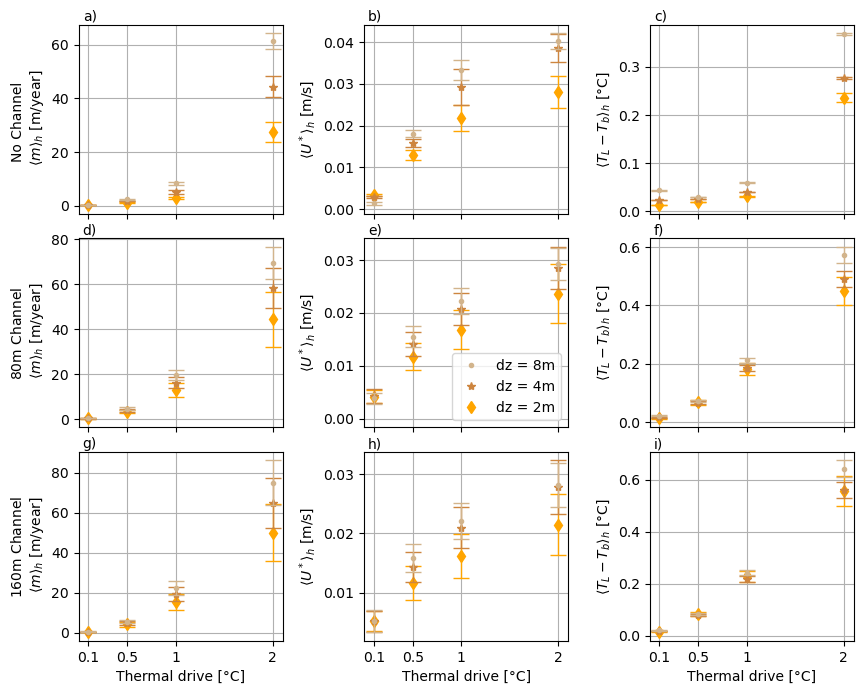

In [31]:

fig = plt.figure(figsize=(10,8))

gs = GridSpec(6, 3, figure=fig)
######## Time series ##########
ax1 = fig.add_subplot(gs[0:2,  0])
ax2 = fig.add_subplot(gs[2:4,  0])
ax3 = fig.add_subplot(gs[4::, 0])
ax4 = fig.add_subplot(gs[0:2,  1])
ax5 = fig.add_subplot(gs[2:4, 1])
ax6 = fig.add_subplot(gs[4::, 1])
ax7 = fig.add_subplot(gs[0:2,  2])
ax8 = fig.add_subplot(gs[2:4, 2])
ax9 = fig.add_subplot(gs[4::, 2])



for var in np.flip(M_mean.data_vars):
    if "ryan" in var:
        continue
    
    if "dz8" in var:
        color="tan"
        marker="."
    elif "dz4" in var:
        color="peru"
        marker="*"
    elif "dz2" in var:
        color="orange"
        marker="d"
        
    if "c80m" in var:
        linestyle="-"
    elif "c160m" in var:
        linestyle="--"
    elif "c0m" in var:
        linestyle="-."
    
##### Melt rate vs Channel #####

    cond = ("vshift12_dz8" in var or "vshift24_dz4" in var or "vshift48_dz2" in var)
    
    if "c0m" in var and cond:
        print(var)
        tdrive = var.split("Td")[1].split("_v")[0]
        if tdrive.startswith("0"):
            tdrive=float(tdrive)/10
        else:
            tdrive=float(tdrive)
        
        Melt = M[var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Melt_std = M[var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax1.plot(tdrive, Melt, marker=marker, color=color)
        ax1.errorbar(tdrive , Melt,  Melt_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
    
    ##### U star vs Channel #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        Ustar_plot = Ustar[ustar_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Ustar_std = Ustar[ustar_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax4.plot(tdrive, Ustar_plot, marker=marker, color=color)
        ax4.errorbar(tdrive , Ustar_plot,  Ustar_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
        
    ##### TD vs Channel #####
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Tf_std = RdrLoc[tf_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax7.plot(tdrive, Tf, marker=marker, color=color)
        ax7.errorbar(tdrive , Tf,  Tf_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
    
    if "c80m" in var and cond:
        print(var)
        tdrive = var.split("Td")[1].split("_v")[0]
        if tdrive.startswith("0"):
            tdrive=float(tdrive)/10
        else:
            tdrive=float(tdrive)
        
        Melt = M[var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Melt_std = M[var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax2.plot(tdrive, Melt, marker=marker, color=color)
        ax2.errorbar(tdrive , Melt,  Melt_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
    
    ##### U star vs Channel #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        Ustar_plot = Ustar[ustar_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Ustar_std = Ustar[ustar_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax5.plot(tdrive, Ustar_plot, marker=marker, color=color)
        ax5.errorbar(tdrive , Ustar_plot,  Ustar_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
        
    ##### TD vs Channel #####
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Tf_std = RdrLoc[tf_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax8.plot(tdrive, Tf, marker=marker, color=color)
        ax8.errorbar(tdrive , Tf,  Tf_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)

    if "c160m" in var and cond:
        print(var)
        tdrive = var.split("Td")[1].split("_v")[0]
        if tdrive.startswith("0"):
            tdrive=float(tdrive)/10
        else:
            tdrive=float(tdrive)
        
        Melt = M[var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Melt_std = M[var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax3.plot(tdrive, Melt, marker=marker, color=color)
        ax3.errorbar(tdrive , Melt,  Melt_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
    
    ##### U star vs Channel #####
        ustar_var = var.replace("SHIfwFlx","SHIuStar")
        Ustar_plot = Ustar[ustar_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Ustar_std = Ustar[ustar_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax6.plot(tdrive, Ustar_plot, marker=marker, color=color)
        ax6.errorbar(tdrive , Ustar_plot,  Ustar_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)
        
    ##### TD vs Channel #####
        tf_var = var.replace("SHIfwFlx","SHI_TmTb")
        Tf = RdrLoc[tf_var].mean(("XC","YC")).dropna("time").isel(time=-1)
        Tf_std = RdrLoc[tf_var].std(("XC","YC")).dropna("time").isel(time=-1)
        ax9.plot(tdrive, Tf, marker=marker, color=color)
        ax9.errorbar(tdrive , Tf,  Tf_std, linestyle='None' ,color=color, fmt='', linewidth=1, capsize=6)

        
ax1.set_ylabel("No Channel \n "+r"$\left<m\right>_h$ [m/year]")
ax2.set_ylabel("$80$m Channel \n "+r"$\left<m\right>_h$ [m/year]")
ax3.set_ylabel("$160$m Channel \n "+ r"$\left<m\right>_h$ [m/year]")
ax4.set_ylabel(r"$\left<U^*\right>_h$"+" [m/s]")
ax5.set_ylabel(r"$\left<U^*\right>_h$"+" [m/s]")
ax6.set_ylabel(r"$\left<U^*\right>_h$"+" [m/s]")
ax7.set_ylabel(r"$\left<T_L-T_b\right>_h$"+" [°C]")
ax8.set_ylabel(r"$\left<T_L-T_b\right>_h$"+" [°C]")
ax9.set_ylabel(r"$\left<T_L-T_b\right>_h$"+" [°C]")


ax5.plot(-1,0,color="tan",marker=".",label="dz = 8m",linestyle='')
ax5.plot(-1,0,color="peru",marker="*",label="dz = 4m",linestyle='')
ax5.plot(-1,0,color="orange",marker="d",label="dz = 2m",linestyle='')
# ax5.set_ylim((0.0,2.1))

ax5.legend()
[a.set_xlim((0.0,2.1)) for a in [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9]]
[a.set_xticks([0.1,0.5,1,2], labels=[0.1,0.5,1,2]) for a in [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9]]
[a.grid() for a in [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9]]
[a.xaxis.set_ticklabels([]) for a in [ax1,ax2,ax4,ax5,ax7,ax8]]
[a.set_xlabel("Thermal drive [°C]") for a in [ax3,ax6,ax9]]

plt.subplots_adjust(wspace=0.4, hspace=0.3)

ax1.text(0.02, 1.02, "a)", fontsize=10, transform=ax1.transAxes)
ax4.text(0.02, 1.02, "b)", fontsize=10, transform=ax4.transAxes)
ax7.text(0.02, 1.02, "c)", fontsize=10, transform=ax7.transAxes)
ax2.text(0.02, 1.02, "d)", fontsize=10, transform=ax2.transAxes)
ax5.text(0.02, 1.02, "e)", fontsize=10, transform=ax5.transAxes)
ax8.text(0.02, 1.02, "f)", fontsize=10, transform=ax8.transAxes)
ax3.text(0.02, 1.02, "g)", fontsize=10, transform=ax3.transAxes)
ax6.text(0.02, 1.02, "h)", fontsize=10, transform=ax6.transAxes)
ax9.text(0.02, 1.02, "i)", fontsize=10, transform=ax9.transAxes)

plt.savefig('./figures/SFig_6_thermal_forcing.pdf', dpi=300, bbox_inches='tight')